# Topic modeling example



## Running with Colaboratory

As of March 2023, this notebook runs in colaboratory.

## Running with Anaconda / Jupyter

As of March 2023, this notebook will not run in Jupyter, mainly due to colab's use of older pyLDAvis and gensim packages, which use deprecated or changed methods and attributes. A separate version of this notebook is available in the github repository which uses more recent packages, and which will run in Jupyter provided the correct versions of those packages are installed via conda.



## Introduction

This exercise introduces topic modeling using the LDA (Latent Dirichlet Allocation) algorithm and the Non-negative Matrix Factorisation (NMF) algorithm.

Topic modeling is an unsupervised approach that allows you to explore large text collections.

In this example, we use the gensim LDA and pyLDAvis implementations for one type of analysis, as well as the sklearn implementations of LDA and NMF to look at how the models relate to categories in the data.

The main packages that are used in this example are:

nltk: http://www.nltk.org/ - for preprocessing

gensim: https://radimrehurek.com/gensim/ - for building the LDA model

pyLDAvis: https://github.com/bmabey/pyLDAvis - for visualization and easier exploration of the generated topics

sklearn: https://scikit-learn.org/stable/, https://scikit-learn.org/stable/modules/decomposition.html#nmf - for building LDA and NMF models

The example is inspired by, and uses functions from: http://nbviewer.jupyter.org/github/bmabey/pyLDAvis/blob/master/notebooks/Gensim%20Newsgroup.ipynb
and
https://github.com/derekgreene/topic-model-tutorial/blob/master/2%20-%20NMF%20Topic%20Models.ipynb

Written by: Sumithra Velupillai, with input from Sonia Priou, February 2019, updated 2025

In [ ]:
# We will install gensim, a Python language modelling library
# that includes some embedding model implementations
!pip install --upgrade gensim

# At the time of writing, there was a bug in gensim. It can
# be worked round by restarting your colab runtime. We do it
# in code here, using the os (operating system) package and the
# its kill method.
import os
os.kill(os.getpid(), 9)

In [1]:
## Now we need to import all the necessary packages

# As of May 2025, use pyLDAvis 3.4.1 for pandas
# compatability
!pip install --upgrade pyLDAvis==3.4.1

import string
from gensim import models
from gensim.corpora import Dictionary, MmCorpus
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
import itertools
import zipfile

try:
    import pyLDAvis
except ImportError as e:
    !pip install  --upgrade pyLDAvis==3.4.1
    import pyLDAvis

import pyLDAvis.gensim as gensimvis
from IPython.display import HTML
import os
import pandas as pd

import re
import codecs
from sklearn.utils import shuffle
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

import numpy as np
from sklearn.decomposition import NMF, LatentDirichletAllocation
import zipfile

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings; warnings.simplefilter('ignore')

from datetime import datetime
print(datetime.now())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


2026-03-17 03:54:21.235476


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 1: corpus
The first step in building a topic model is to read a corpus, or a collection of documents.

In this example, we are using documents from http://www.mtsamples.com/.

These are transcribed medical transcriptions sample reports and examples from a variety of clinical disciplines, such as radiology, surgery, discharge summaries. Note that one document can belong to several categories.

We will save each document, all its words, and which clinical specialty it belongs to, in a dataframe.


In [2]:
file_path = r'/content/mtsamples_for_topic_modelling.xlsx'
df = pd.read_excel(file_path)

How many documents are in the data?

In [3]:
len(df)

6385

How many clinical specialties are in the data?

In [4]:
df['Category'].value_counts()

,count
Category,
85-surgery,1103
97-consult-historyandphy.,516
97-consult,516
6-cardiovascularpulmonary,372
49-orthopedic,355
95-radiology,273
98-general,259
98-generalmedicine,259
24-gastroenterology,230


We need to convert the texts to words - let's use a very simple approach

In [5]:
lemmatizer = WordNetLemmatizer()

def getWords(row):

    return [lemmatizer.lemmatize(''.join(c.lower() for c in s if c not in string.punctuation)) for s in nltk.word_tokenize(row)]

df['Document words'] = df['Document Content'].apply(getWords)


# 2 Using gensim and pyLDAVis

We now need to generate representations for the vocabulary (dictionary) and the text collection (corpus)

Let's use some functions that we can call later, and that we can modify later if we want.

(Using all the words in the whole corpus or text collection is not typically what you want, because very common words,

or very rare words will not generate good topic representations. Why?

What parameters and configurations could be interesting to change below?)

### Why do very rare words fail to generate good topic representations?
1. If a word appears only once or twice, the algorithm cannot determine whether it is merely random noise or a meaningful term that represents the core characteristics of a particular type of document.

2. Topics are discovered through the **co-occurrence** of words. Because rare words appear too infrequently, it is difficult for them to form stable **co-occurrence** relationships with other words. As a result, they contribute little to helping the model group similar documents into the same topic.

3. In NLP, the size of the vocabulary directly determines the dimensionality of the computational matrix. Removing thousands of words that appear only once(such as rare terms or misspellings), can substantially improve training efficiency and reduce the risk of model **overfitting**.


###What parameters and configurations could be interesting to change below?
1. In the **prep_corpus** function, the value of **no_below** can be increased to **10 or 20**. This adjustment tends to make the resulting topics more **general**, as the value **5** may retain more low-frequency detail words. In addition, **no_above** can be reduced from **0.5** to **0.2 or 0.3**. This forces the model to remove very common **domain-generic words** (such as “patient” or “procedure”), encouraging it to identify more **department-specific or specialized terminology**.

2. In the call to **LdaModel**, the parameter **num_topics** can be increased from **10** to **30**, which allows the model to produce a **more fine-grained topic structure**. The parameter **passes** can also be increased from **10** to **50**, enabling the model to iterate over the corpus more times. This typically helps the topics **converge more effectively** and results in **clearer and more coherent word groupings**.

In [6]:

## functions from http://nbviewer.jupyter.org/github/bmabey/pyLDAvis/blob/master/notebooks/Gensim%20Newsgroup.ipynb

## this function returns a set of stopwords predefined in the nltk package

def nltk_stopwords():
    return set(nltk.corpus.stopwords.words('english'))

## this function prepares the data and returns a dictionary and a corpus.
## which parameters do you think would be worth modifying/experimenting with?

def prep_corpus(docs, additional_stopwords=set(), no_below=5, no_above=0.5):
  print('Building dictionary...')
  dictionary = Dictionary(docs)
  stopwords = nltk_stopwords().union(additional_stopwords)
  stopword_ids = map(dictionary.token2id.get, stopwords)
  dictionary.filter_tokens(stopword_ids)
  dictionary.compactify()
  dictionary.filter_extremes(no_below=no_below, no_above=no_above, keep_n=None)
  dictionary.compactify()

  print('Building corpus...')
  corpus = [dictionary.doc2bow(doc) for doc in docs]

  return dictionary, corpus




In [7]:
## now, let's use the functions we defined above to get our dictionary and corpus
dictionary, corpus = prep_corpus(df['Document words'])

Building dictionary...
Building corpus...


In [8]:
## If you want, you can save your corpus and dictionary to disk for quicker processing later
## For colab, try this:

from google.colab import drive
drive.mount('/content/gdrive') # to mount the google drive
MmCorpus.serialize("gdrive/My Drive/Colab Notebooks/mtsamples.mm", corpus)
dictionary.save("gdrive/My Drive/Colab Notebooks/mtsamples.dict")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [9]:
## Now we have our dictionary and corpus, let's generate an LDA model.
## The LDA model has many parameters that can be set, all available parameters can be found here:
## https://radimrehurek.com/gensim/models/ldamodel.html

## Here, we've set the number of topics to 10.

lda = models.ldamodel.LdaModel(corpus=corpus, id2word=dictionary, num_topics=10, passes=10)

## You can also save the generated model to disk if you want
#lda.save('/Users/sumithra/DSV/MeDESTO/teaching/Farr2017/data/gensim_topic_model_data/mtsamples_20_lda.model')

In [10]:
## you can now look at these topics by printing them from the generated model

lda.print_topics()

[(0,
  '0.015*"mg" + 0.011*"pain" + 0.008*"denies" + 0.006*"doe" + 0.005*"blood" + 0.005*"also" + 0.005*"daily" + 0.005*"po" + 0.005*"medical" + 0.005*"medication"'),
 (1,
  '0.015*"pain" + 0.007*"extremity" + 0.006*"examination" + 0.006*"back" + 0.006*"time" + 0.006*"knee" + 0.006*"mri" + 0.006*"lower" + 0.005*"doe" + 0.005*"also"'),
 (2,
  '0.010*"bladder" + 0.009*"mass" + 0.009*"biopsy" + 0.009*"renal" + 0.008*"kidney" + 0.008*"cm" + 0.007*"ct" + 0.007*"x" + 0.007*"abdomen" + 0.007*"tumor"'),
 (3,
  '0.011*"quot" + 0.008*"time" + 0.006*"year" + 0.006*"also" + 0.006*"reported" + 0.005*"mother" + 0.005*"test" + 0.005*"memory" + 0.004*"doe" + 0.004*"difficulty"'),
 (4,
  '0.007*"pain" + 0.006*"reveals" + 0.005*"show" + 0.005*"present" + 0.005*"exam" + 0.004*"bowel" + 0.004*"medical" + 0.004*"obstruction" + 0.004*"surgery" + 0.004*"1"'),
 (5,
  '0.010*"blood" + 0.007*"day" + 0.006*"time" + 0.006*"also" + 0.005*"count" + 0.005*"renal" + 0.005*"creatinine" + 0.004*"hospital" + 0.004*"room

In [14]:

## It can be hard to get a good understanding of what's actually in these topics
## Visualizations are very helpful for this, let's use a package that does this:

vis_data = gensimvis.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(vis_data, 'lda_vis.html')
path = os.path.abspath('lda_vis.html')
display(HTML(pyLDAvis.prepared_data_to_html(vis_data)))

Take a look at the results. What observations do you have? What happens if you change the number of topics?

1. In the bar chart, the **Top 5 most salient terms** are *pain*, *placed*, *mg*, *without*, and *procedure*. Although these words are very common in medical records, their extremely high frequency means they provide little useful information for analytical purposes. For example, “mg” refers to dosage; while it is a medical term, it does not help distinguish between specialties such as **cardiology** and **orthopaedics**. This suggests that the model is currently being influenced by **background noise terms**.

2. **Severe topic overlap**. In the visualizations on the left, **Topic 2,** **Topic 5**, and **Topic 6** almost overlap with each other. This indicates that these topics share a large proportion of vocabulary, meaning the model has not successfully separated them into distinct themes. This may imply that the **num_topics** **parameter is set too high**, or that the **data preprocessing is not sufficiently clean**.

3. When examining the **most salient terms within each topic**, some topics still contain vocabulary that is too generic within the medical domain to clearly indicate a specific clinical specialty. However, the model has nevertheless successfully captured several highly representative specialized fields. For example, **Topic 9** contains high-frequency terms such as *artery*, *vein*, and *coronary*, which strongly reflect **cardiovascular or circulatory system characteristics**. **Topic 8** includes terms such as *bladder*, *tube*, and *uterus*, which are highly associated with **gynaecological surgery and clinical procedures**. Meanwhile, **Topic 7** contains high-frequency terms such as *renal*, *vein*, and *ureter*, which clearly point to **urological or vascular interventional surgical practices**.

# 3 Using sklearn and comparing with 'existing' categories

Now you have seen how you can build a topic models with gensim and look at the contents visually with pyLDAVis.

You can also use sklearn for topic modeling, both lda and nmf, and analyse results visually by comparing with existing categories, if you have them.

NMF approaches can be very efficient, particularly with smaller datasets. Let's see what you think.



In [12]:
# We need a couple of functions to visualise the data
# Preparation for visualisation
# Written by Sonia Priou, adaptations by Sumithra Velupillai

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic %d:" % (topic_idx))
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

def get_topic_list(model, feature_names, no_top_words):
    tlist = {}
    for topic_idx, topic in enumerate(model.components_):
        tlist[topic_idx]= str("%d: " % (topic_idx)+", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
    return tlist


def display_topic_representation (model,dataframe,tlist):
    doc_topic = model    #example : model = lda_Tfidf.transform(tfidf)
    doc = np.arange(doc_topic.shape[0])
    num_topics = doc_topic.shape[1]
    dico = {'index': doc}
    for n in range(num_topics):
        dico["topic" + str(n)] = doc_topic[:,n]

    #Max topic
    Topic_max = []
    for i in range(doc_topic.shape[0]):
        if len(set(doc_topic[i])) == 1:
            Topic_max.append(num_topics+1)
        else:
            Topic_max.append(doc_topic[i].argmax())
    dico["Topic most represented"] = Topic_max
    #print(Topic_max)
    tlist[num_topics+1] = 'NONE'
    dico["Topic and its most representative words"] = [tlist[x] for x in Topic_max]
    df_topic = pd.DataFrame(dico)


    #Link both DataFrame
    df_result = pd.merge(dataframe,df_topic, on='index')
    df_result = df_result.sort_values('Topic most represented')

    #Finding within the cluster found by LDA the original file
    fig, ax = plt.subplots()
    fig.set_size_inches(11.7, 8.27)
    sns.set_style('whitegrid')
    sns.countplot(y='Topic and its most representative words', data = df_result)
    return df_result

def display_file_representation (model,dataframe):
    #Within a file, what is the slipt between topics found
    doc_topic = model    #example : model = lda_Tfidf.transform(tfidf)
    doc = np.arange(doc_topic.shape[0])
    no_topics = doc_topic.shape[1]
    topic = np.arange(no_topics)
    dico = {'index': doc}
    for n in range(no_topics):
        dico["topic" + str(n)] = doc_topic[:,n]
    #Max topic
    Topic_max = []
    for i in range(doc_topic.shape[0]):
        Topic_max.append(doc_topic[i].argmax())
    dico["Topic most represented"] = Topic_max
    df_topic = pd.DataFrame(dico)
    #print(df_topic)


    #Link both DataFrame
    df_result = pd.merge(dataframe,df_topic, on='index')

    dico2 = {'Topic': topic}
    for i in df_result['Category'].value_counts().index:
        ser = df_result.loc[df_result['Category']==i].mean(numeric_only=True)
        score = ser[2:no_topics+2]
        dico2[i]=score

    df_score = pd.DataFrame(dico2)
    print('For each given file, we calculate the mean percentage of the documents depence to each topic')
    print('')
    print(df_score)
    print(df_result['Category'].value_counts().index)

    fig, axs = plt.subplots(ncols=len(dataframe['Category'].value_counts()))
    count = 0
    for i in df_result['Category'].value_counts().index:
        sns.barplot(x='Topic', y =i ,data = df_score, ax=axs[count])
        count = count + 1

    plt.tight_layout()

Let's look at a smaller sample, to make the analysis a bit easier. You can choose other categories of course!

In [13]:
categories_to_keep = ['17-dentistry', '46-ophthalmology', '72-psychiatrypsychology', '71-podiatry']
df_smaller = df.loc[df['Category'].isin(categories_to_keep)]
#new_df = df.drop(df_smaller)
new_df = df[~df.isin(df_smaller)]
df_smaller['index'] = range(0,len (df_smaller))
df_smaller.head()

,Unnamed: 0,index,Category,Document Name,Document Content,Document words
475,475,0,17-dentistry,2336-bonyimpactedteethremoval.txt,PREOPERATIVE D...,"[preoperative, diagnosis, , completely, bony, ..."
476,476,1,17-dentistry,1260-dentalpain-emergencyvisit.txt,CHIEF COMPLAIN...,"[chief, complaint, , dental, painhistory, of, ..."
477,477,2,17-dentistry,2748-jawpain-ervisit.txt,CHIEF COMPLAIN...,"[chief, complaint, , jaw, painhistory, of, pre..."
478,478,3,17-dentistry,1916-odontogenicabscessid.txt,PREOPERATIVE D...,"[preoperative, diagnoses1, , left, facial, cel..."
479,479,4,17-dentistry,2338-teethextractionid.txt,PREOPERATIVE D...,"[preoperative, diagnoses1, , carious, teeth, ,..."


Now let's use sklearn's function for converting corpora to document-term-matrices. We'll define a function for this, which takes as parameters a dataframe, the name of the text column that should be transformed to tf-idf, and some optional parameters for thresholds in creating the model. These thresholds can of course be changed!

In [14]:
def get_tfidf_model(dataframe, text_column, min_df = 5, max_df=100000, lowercase = True):
    stopwords = nltk.corpus.stopwords.words('english')
    min_df = 5
    max_df = 100000
    lowercase = True


    bow_transformer = CountVectorizer(stop_words=stopwords,
                                  min_df=min_df,
                                  max_df=max_df,
                                  lowercase = lowercase).fit(dataframe[text_column])
    document_bow = bow_transformer.transform(dataframe[text_column])
    feature_names = bow_transformer.get_feature_names_out()

    tfidf_transformer = TfidfTransformer().fit(document_bow)
    document_tfidf= tfidf_transformer.transform(document_bow)
    return feature_names, document_tfidf

Let's also define some functions to train the different topic models - we're using NMF and LDA with some preset parameters, these can of course be changed - check out the documentation to see what parameters are available. Note that the two functions return different variables.

In [15]:
def getNMFModel(no_topics, document_tfidf):
    nmf = NMF(n_components=no_topics)
    W = nmf.fit_transform(document_tfidf)
    H = nmf.components_
    return nmf, W, H

def getLDAModel(no_topics, document_tfidf):
    lda = LatentDirichletAllocation(n_components=no_topics).fit(document_tfidf)
    return lda

Now let's convert our data to a tfidf model and get the feature names from that model (i.e. the vocabulary)

In [16]:
feature_names, document_tfidf = get_tfidf_model(df_smaller, 'Document Content')

How many features does the model contain? What parameters can you change?

The model contains **2238** features.


We can modify the following parameters:

1. The specific medical specialties and the number of categories included in **categories_to_keep**.

2. The values of **min_df** and **max_df** in the **get_tfidf_model** function.

In [17]:
print(len(feature_names))

2238


### Optional
What's in the variable feature_names? How can you take a look?

In [20]:
print(list(feature_names))

['00', '000', '01', '03', '04', '05', '06', '07', '08', '09', '10', '100', '11', '12', '120', '13', '14', '15', '16', '17', '18', '19', '1997', '1999', '20', '200', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2009', '21', '22', '23', '24', '25', '250', '26', '27', '28', '29', '30', '300', '31', '32', '33', '35', '36', '360', '37', '40', '41', '42', '43', '44', '45', '48', '49', '4h', '4s', '4x4s', '50', '500', '51', '54', '55', '58', '60', '62', '65', '650', '69', '6h', '70', '75', '77', '80', '81', '8h', '90', '97', '98', '________', 'abc', 'abcd', 'abdomen', 'abdominal', 'abilities', 'ability', 'able', 'abnormal', 'abnormalities', 'abnormality', 'abscess', 'absence', 'absent', 'abuse', 'abusive', 'academic', 'access', 'accident', 'accompanied', 'accomplished', 'according', 'accurate', 'accurately', 'ace', 'achieve', 'achieved', 'across', 'act', 'active', 'activities', 'activity', 'actual', 'actually', 'acuity', 'acute', 'addition', 'additional', 'address', 'addressed', '

### Number of topics and top words for each topic
* How many topics do you want the model to generate?
* How many discriminative words from each topic do you want to look at?

In [21]:
## In this case, we know that there are four categories in the dataset,
## let's see if the models produce something coherent with that number
no_topics = 4

## Each topic is represented with a list of words, ranked according to how discriminative they are for that topic.
## We can use the top ranked words to try to understand what the topic represents.
no_top_words = 10

Now let's build an lda model

In [22]:
lda = getLDAModel(no_topics, document_tfidf)

### Most discriminative words - LDA
Let's look at the most discriminative words for each topic generated from our LDA model. Do you see a pattern? Do they make sense? Do you think more work needs to be done, e.g. with parameters, with the underlying representation, or other things?

These LDA topics show clear, clinically meaningful patterns: Topics 0 and 2 focus on f**ungal nail disease** (**onychomycosis**), Topic 1 centers on **ophthalmic procedures**, and Topic 3 covers **foot or ankle musculoskeletal issues**, all coherent and medically interpretable.

While the model already produces sensible results, further work is needed: **refine parameters** (e.g., adjust the number of topics, increase the number of top words displayed), **improve preprocessing** (filter generic medical stopwords, correct typos), and **check for topic overlap or collapse** to boost clarity and distinctiveness between themes.

In [23]:
display_topics(lda,feature_names, no_top_words)

Topic 0:
hypertrophic, nails, absent, vascular, onychomycosis, interpretation, neosporin, calcaneus, reapproximated, imaging
Topic 1:
patient, eye, right, history, left, procedure, placed, used, quot, chamber
Topic 2:
nails, absent, hypertrophic, vascular, refer, growth, debrided, pedal, onychomycosis, request
Topic 3:
foot, tendon, ankle, toe, plantar, metatarsal, proximal, joint, bone, fifth


We can now look at the distribution of the main topic (i.e. the topic with highest probability) for each document.

Representation of the main topic for each document in the document collection


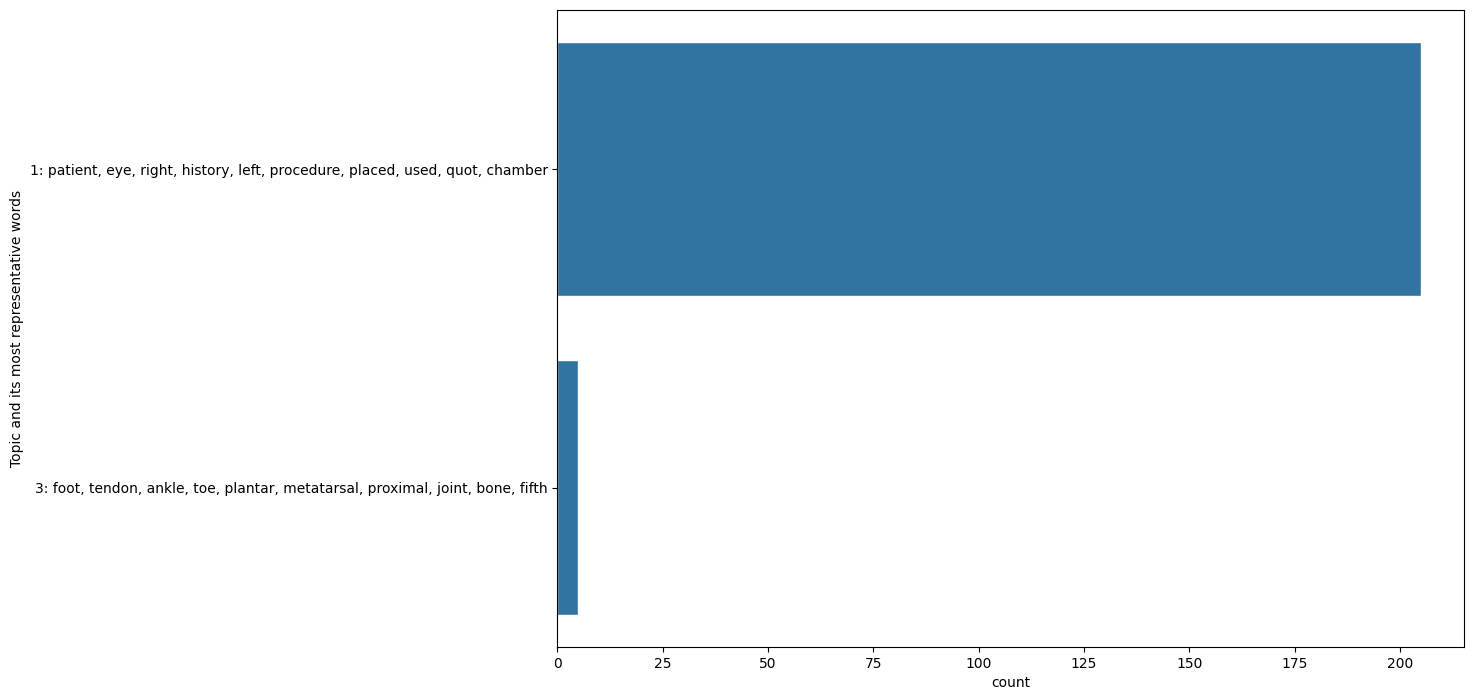

In [24]:
print('Representation of the main topic for each document in the document collection')
tlist = get_topic_list(lda,feature_names, 10)
df_result = display_topic_representation(lda.transform(document_tfidf),df_smaller,tlist)

Does this look reasonable to you? Are all the topics represented? How do you interpret these results?

This result is **not fully reasonable** and shows clear imbalances: only Topic 1 (ophthalmic procedures) and Topic 3 (foot or ankle musculoskeletal issues) are represented as the main topic across documents, with Topic 1 dominating nearly all entries, while Topic 0 and Topic 2 (fungal nail disease) are **entirely absent** from the distribution.

This suggests the LDA model has failed to capture the smaller, domain-specific signals of nail-related topics, likely due to a heavy skew toward ophthalmic content in the corpus, insufficient weighting of low-frequency specialized terms, or overly generic stopwords that dilute niche medical signals.

There's a new column saved in the dataframe that contains the topic number that had the highest probability, we can look at the distribution of those.

In [25]:
df_result['Topic most represented'].value_counts()

,count
Topic most represented,
1,205
3,5


We can also look at the probability scores each topic resulted in in the whole document collection and get some descriptive statistics. Look at some of the other topics!

In [26]:
df_result['topic1'].describe()

,topic1
count,210.000000
mean,0.865599
std,0.154771
min,0.056627
25%,0.905331
50%,0.925208
75%,0.936135
max,0.956114


Now let's look at the distribution of topics in the files in relation to the 'existing' categories in the dataset. We'll use the function we defined earlier.

For each given file, we calculate the mean percentage of the documents depence to each topic

        Topic  46-ophthalmology  72-psychiatrypsychology  71-podiatry  \
topic0      0          0.026087                 0.020793     0.026894   
topic1      1          0.921538                 0.937566     0.651120   
topic2      2          0.026087                 0.020793     0.033058   
topic3      3          0.026288                 0.020848     0.288928   

        17-dentistry  
topic0      0.024672  
topic1      0.925724  
topic2      0.024671  
topic3      0.024933  
Index(['46-ophthalmology', '72-psychiatrypsychology', '71-podiatry',
       '17-dentistry'],
      dtype='object', name='Category')


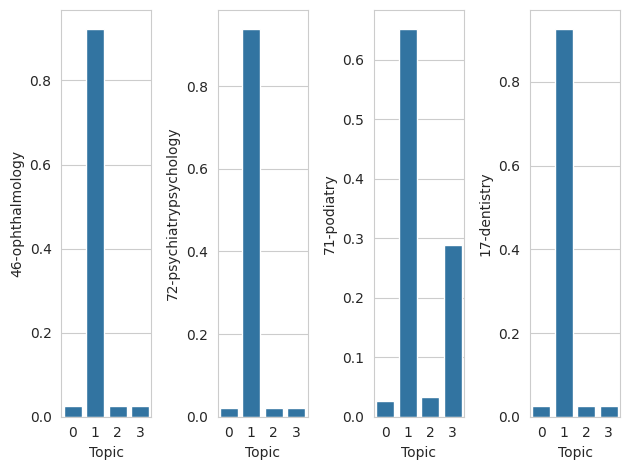

In [27]:
display_file_representation(lda.transform(document_tfidf),df_smaller)

### NMF
Now let's compare with NMF.  

In [28]:
nmf, W, H = getNMFModel(no_topics, document_tfidf)

In [29]:
display_topics(nmf, feature_names, no_top_words)

Topic 0:
eye, chamber, lens, anterior, cataract, right, bag, used, capsular, intraocular
Topic 1:
patient, history, quot, mg, axis, mother, past, disorder, denies, family
Topic 2:
foot, left, right, ankle, tendon, plantar, metatarsal, patient, proximal, lateral
Topic 3:
teeth, tooth, dental, patient, caries, mandible, procedure, left, ml, placed


Representation of the main topic for each document


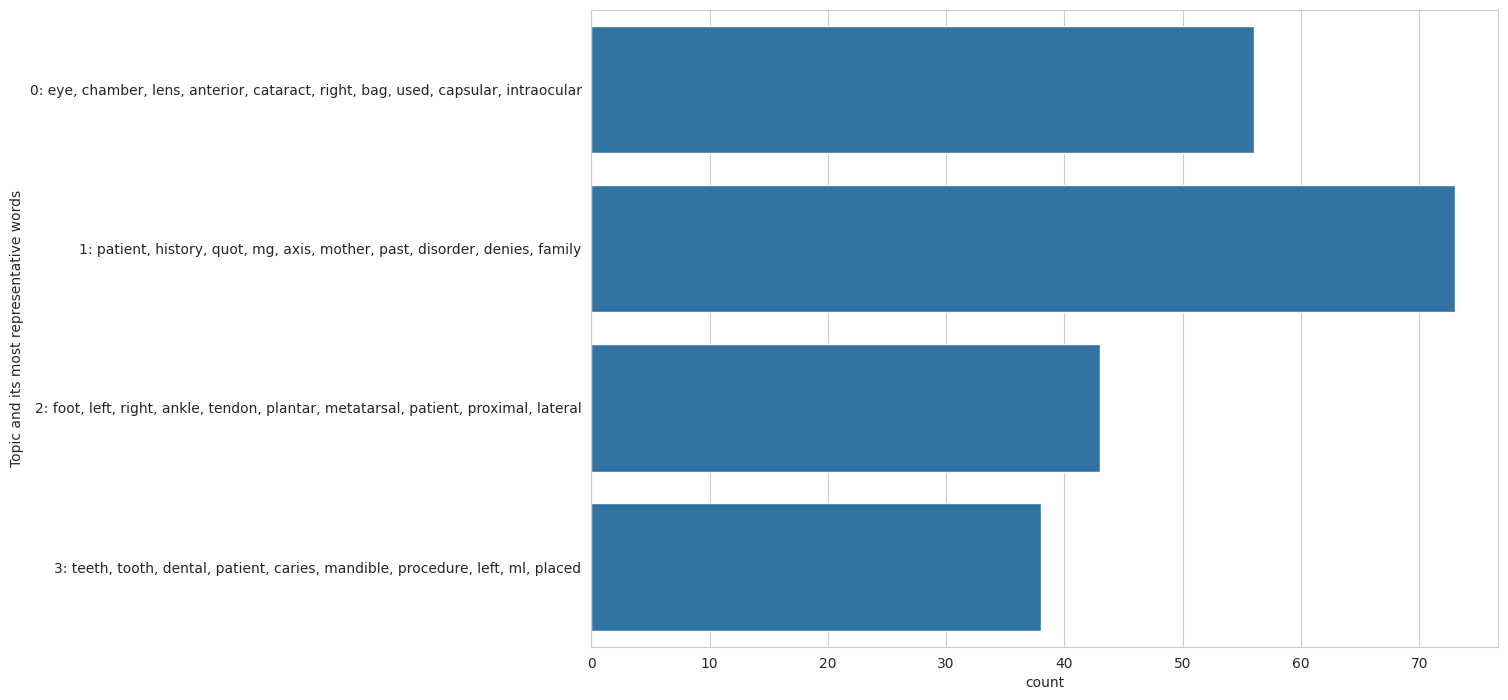

In [30]:
print('Representation of the main topic for each document')

tlist = get_topic_list(nmf,feature_names, 10)
df_result = display_topic_representation(W,df_smaller,tlist)


For each given file, we calculate the mean percentage of the documents depence to each topic

          Topic  46-ophthalmology  72-psychiatrypsychology  71-podiatry  \
topic0_x      0          0.152949                 0.000244     0.004346   
topic1_x      1          0.029997                 0.270479     0.035026   
topic2_x      2          0.022216                 0.002908     0.247346   
topic3_x      3          0.037790                 0.003080     0.010628   

          17-dentistry  
topic0_x      0.001969  
topic1_x      0.039465  
topic2_x      0.016647  
topic3_x      0.316798  
Index(['46-ophthalmology', '72-psychiatrypsychology', '71-podiatry',
       '17-dentistry'],
      dtype='object', name='Category')


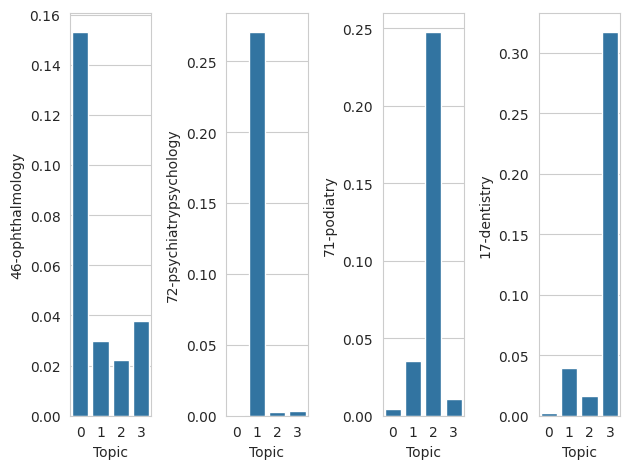

In [31]:
display_file_representation(W,df_result)

## LDA vs NMF?
What do you think about these results and models? What main differences do you notice when comparing NMF and LDA results? Do you think one is better than the other? What parameters might be worth changing?

The NMF model produces far more balanced, clinically meaningful results than LDA: its document-topic distribution shows four distinct, interpretable topics, with clear topic representation across all categories, whereas LDA collapsed nearly all documents into a single ophthalmic topic and erased nail-related signals.

For each given file, NMF also achieves better separation: ophthalmology, psychiatry, podiatry, and dentistry all show distinct topic-preference patterns (e.g., podiatry has strong Topic 2 affinity, dentistry has Topic 3 dominance), whereas LDA forces nearly all specialties into Topic 1. NMF outperforms LDA here because it better captures low-frequency, domain-specific signals (e.g., cataract, plantar, caries) by focusing on term importance rather than probabilistic topic mixing.

For parameter tuning: adjust the number of topics and increase no_top_words to assess topic cohesion; for NMF, tweak alpha/l1_ratio to control sparsity, and for LDA, refine eta to adjust topic-word distribution smoothness.

Overall, NMF is clearly superior for this medical text dataset, as it preserves discriminative specialty-specific patterns that LDA fails to capture.

# Choosing number of topics ('k') - coherence score

There are several metrics proposed for automatically calculating what the 'optimal' number of topics in a document collection is, by trying to measure how coherent generated topics are.

Here, we will use the TC-W2W score proposed by O'Callaghan et al.

O’Callaghan, D., Greene, D., Carthy, J., & Cunningham, P. (2015).
An analysis of the coherence of descriptors in topic modeling.
Expert Systems with Applications, 42(13), 5645-5657

The code is from: https://github.com/derekgreene/topic-model-tutorial/blob/master/3%20-%20Parameter%20Selection%20for%20NMF.ipynb
With slight adaptations for our example.

The main idea with this score is to calculate the pairwise embedding vector similarity for each term pair in the top ranked words in each generated topic.

We need to have a word2vec model first. We'll start by building one on the entire document collection we have. NOTE: this means that we have an 'in-domain' model.

In [32]:
import gensim

w2v_model = gensim.models.Word2Vec(df['Document words'], vector_size=300, min_count=2, batch_words=1000)


How big is the vocabulary in this embedding model?

In [34]:
print( "Model has %d terms" % len(w2v_model.wv) )

Model has 42797 terms


Recap: we can get similarity scores for different word pairs in these types of models. We can try this on a pair of words from the generated topics in our previous NMF model, e.g. topic3 had the words 'teeth' and 'tooth'

In [35]:
w2v_model.wv.similarity('teeth', 'tooth')

np.float32(0.620362)

Next, we need to build topic models with different number of topics assigned. Let's define a range of k to try.

In [36]:
kmin, kmax = 3, 15

Let's try our smaller dataset again, and generate a tfidf-representation to use in the topic models.

In [37]:
feature_names, document_tfidf = get_tfidf_model(df_smaller, 'Document Content')

Now, let's generate NMF topic models for each value of k in our range

In [38]:
from sklearn import decomposition
topic_models = []
# try each value of k
for k in range(kmin,kmax+1):
    print("Applying NMF for k=%d ..." % k )
    # run NMF
    model, W, H =  getNMFModel(k, document_tfidf)
    # store for later
    topic_models.append( (k,W,H) )

Applying NMF for k=3 ...
Applying NMF for k=4 ...
Applying NMF for k=5 ...
Applying NMF for k=6 ...
Applying NMF for k=7 ...
Applying NMF for k=8 ...
Applying NMF for k=9 ...
Applying NMF for k=10 ...
Applying NMF for k=11 ...
Applying NMF for k=12 ...
Applying NMF for k=13 ...
Applying NMF for k=14 ...
Applying NMF for k=15 ...


We need a couple of functions to calculate the coherence score

In [39]:
from itertools import combinations
def calculate_coherence( w2v_model, term_rankings , print_pairs=False):
    overall_coherence = 0.0
    for topic_index in range(len(term_rankings)):
        # check each pair of terms
        pair_scores = []
        for pair in combinations( term_rankings[topic_index], 2 ):
            ## check if word in vocabulary first!! Added by Sumithra
            if pair[0] in w2v_model.wv and pair[1] in w2v_model.wv:
                pair_scores.append( w2v_model.wv.similarity(pair[0], pair[1]) )
                if print_pairs:
                    print(pair[0], pair[1], w2v_model.wv.similarity(pair[0], pair[1]))
            else:
                if print_pairs:
                    print('word pair not in vocabulary', pair[0], pair[1])
                pair_scores.append( 0.0 )
        # get the mean for all pairs in this topic
        topic_score = sum(pair_scores) / len(pair_scores)
        overall_coherence += topic_score
    # get the mean score across all topics
    return overall_coherence / len(term_rankings)

In [40]:
def get_descriptor( all_terms, H, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append( all_terms[term_index] )
    return top_terms

Let's calculate the coherence score for each model with k topics.

In [41]:

k_values = []
coherences = []
for (k,W,H) in topic_models:
    # Get all of the topic descriptors - the term_rankings, based on top 10 terms
    term_rankings = []
    for topic_index in range(k):
        term_rankings.append( get_descriptor( feature_names, H, topic_index, 10 ) )
    # Now calculate the coherence based on our Word2vec model
    k_values.append( k )
    coherences.append( calculate_coherence( w2v_model, term_rankings, print_pairs=False ) )
    print("K=%02d: Coherence=%.4f" % ( k, coherences[-1] ) )

K=03: Coherence=0.2309
K=04: Coherence=0.2414
K=05: Coherence=0.1955
K=06: Coherence=0.2230
K=07: Coherence=0.2015
K=08: Coherence=0.2365
K=09: Coherence=0.2179
K=10: Coherence=0.2025
K=11: Coherence=0.2001
K=12: Coherence=0.1998
K=13: Coherence=0.2008
K=14: Coherence=0.1993
K=15: Coherence=0.2286


We can plot this to visualise

In [42]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

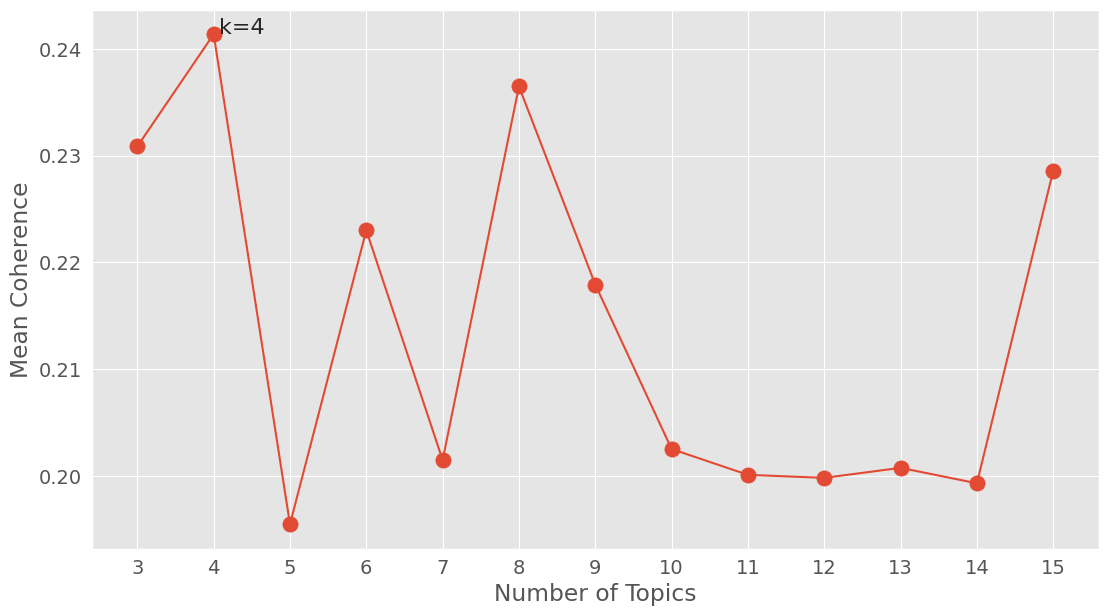

In [43]:
fig = plt.figure(figsize=(13,7))
# create the line plot
ax = plt.plot( k_values, coherences )
plt.xticks(k_values)
plt.xlabel("Number of Topics")
plt.ylabel("Mean Coherence")
# add the points
plt.scatter( k_values, coherences, s=120)
# find and annotate the maximum point on the plot
ymax = max(coherences)
xpos = coherences.index(ymax)
best_k = k_values[xpos]
plt.annotate( "k=%d" % best_k, xy=(best_k, ymax), xytext=(best_k, ymax), textcoords="offset points", fontsize=16)
# show the plot
plt.show()

What seems to be the 'optimal' number of topics? Does this make sense do you think?

Based on the coherence plot, k=4 appears to be the optimal number of topics, as it achieves the highest mean coherence score (about 0.241), clearly outperforming all other k values. This choice is also clinically sensible for the medical text dataset.

Now let's build a model with this 'k' and look at what the model produces

In [50]:

## Assign a value to no_topics from the results above
no_topics = 4

## How many words do you want as topic descriptors?
no_top_words = 10

In [51]:
nmf, W, H = getNMFModel(no_topics, document_tfidf)

Representation of the main topic for each document


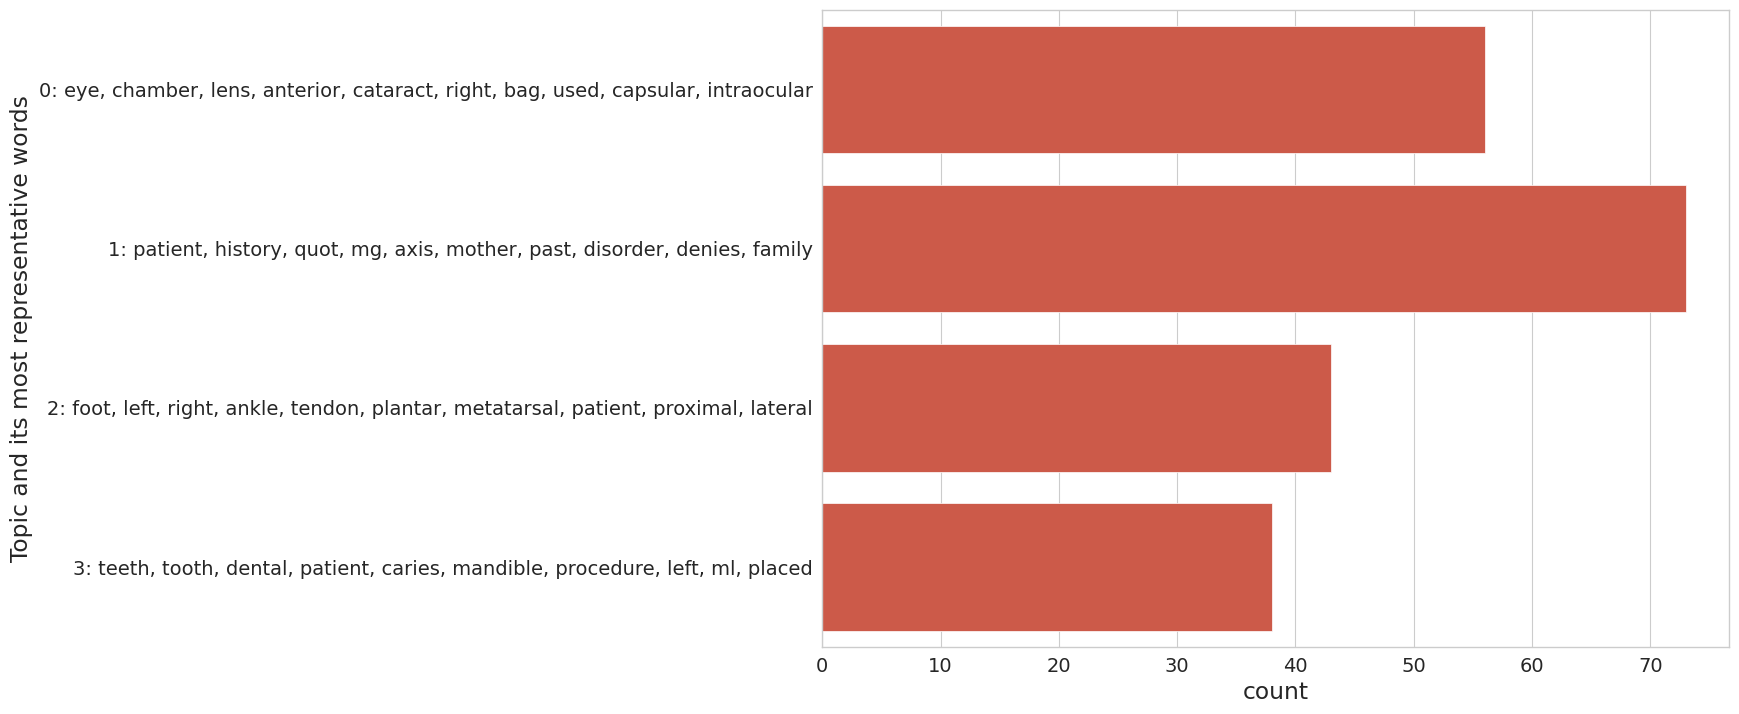

In [52]:
print('Representation of the main topic for each document')

tlist = get_topic_list(nmf,feature_names, 10)
df_result = display_topic_representation(W,df_smaller,tlist)

In [53]:
df_result.head()

,Unnamed: 0,index,Category,Document Name,Document Content,Document words,topic0,topic1,topic2,topic3,Topic most represented,Topic and its most representative words
96,5353,96,46-ophthalmology,1895-phacoemulsificationlensimplantation-1.txt,PREOPERATIVE D...,"[preoperative, diagnosis, , visually, signific...",0.281104,0.034946,0.000000,0.00000,0,"0: eye, chamber, lens, anterior, cataract, rig..."
102,5359,102,46-ophthalmology,181-ophthalmologyprogressnote-2.txt,At today's vis...,"[at, today, s, visit, , the, patient, s, visua...",0.098929,0.064160,0.000000,0.00000,0,"0: eye, chamber, lens, anterior, cataract, rig..."
101,5358,101,46-ophthalmology,2243-phacoemulsificationlensimplantation-3.txt,PREOPERATIVE D...,"[preoperative, diagnosis, , cataract, , right,...",0.257845,0.003654,0.009180,0.00000,0,"0: eye, chamber, lens, anterior, cataract, rig..."
100,5357,100,46-ophthalmology,2090-parsplanavitrectomylensectomy.txt,TITLE OF OPERA...,"[title, of, operation1, , par, plana, vitrecto...",0.191315,0.010776,0.026854,0.02834,0,"0: eye, chamber, lens, anterior, cataract, rig..."
103,5360,103,46-ophthalmology,477-phacoemulsification.txt,PREOPERATIVE D...,"[preoperative, diagnosis, , senile, cataract, ...",0.253503,0.000000,0.000000,0.00000,0,"0: eye, chamber, lens, anterior, cataract, rig..."


In [54]:
# We can also look at the distribution of topics per document.
# We can extract the columns with topic probabilities
# NOTE You will need to edit this to fit with the number of
# topics you set above, and the resulting columm names!

tmp = df_result[['index', 'topic0', 'topic1', 'topic2', 'topic3']]

## Let's sample a few documents
tmp = tmp.sample(5)

Let's plot these

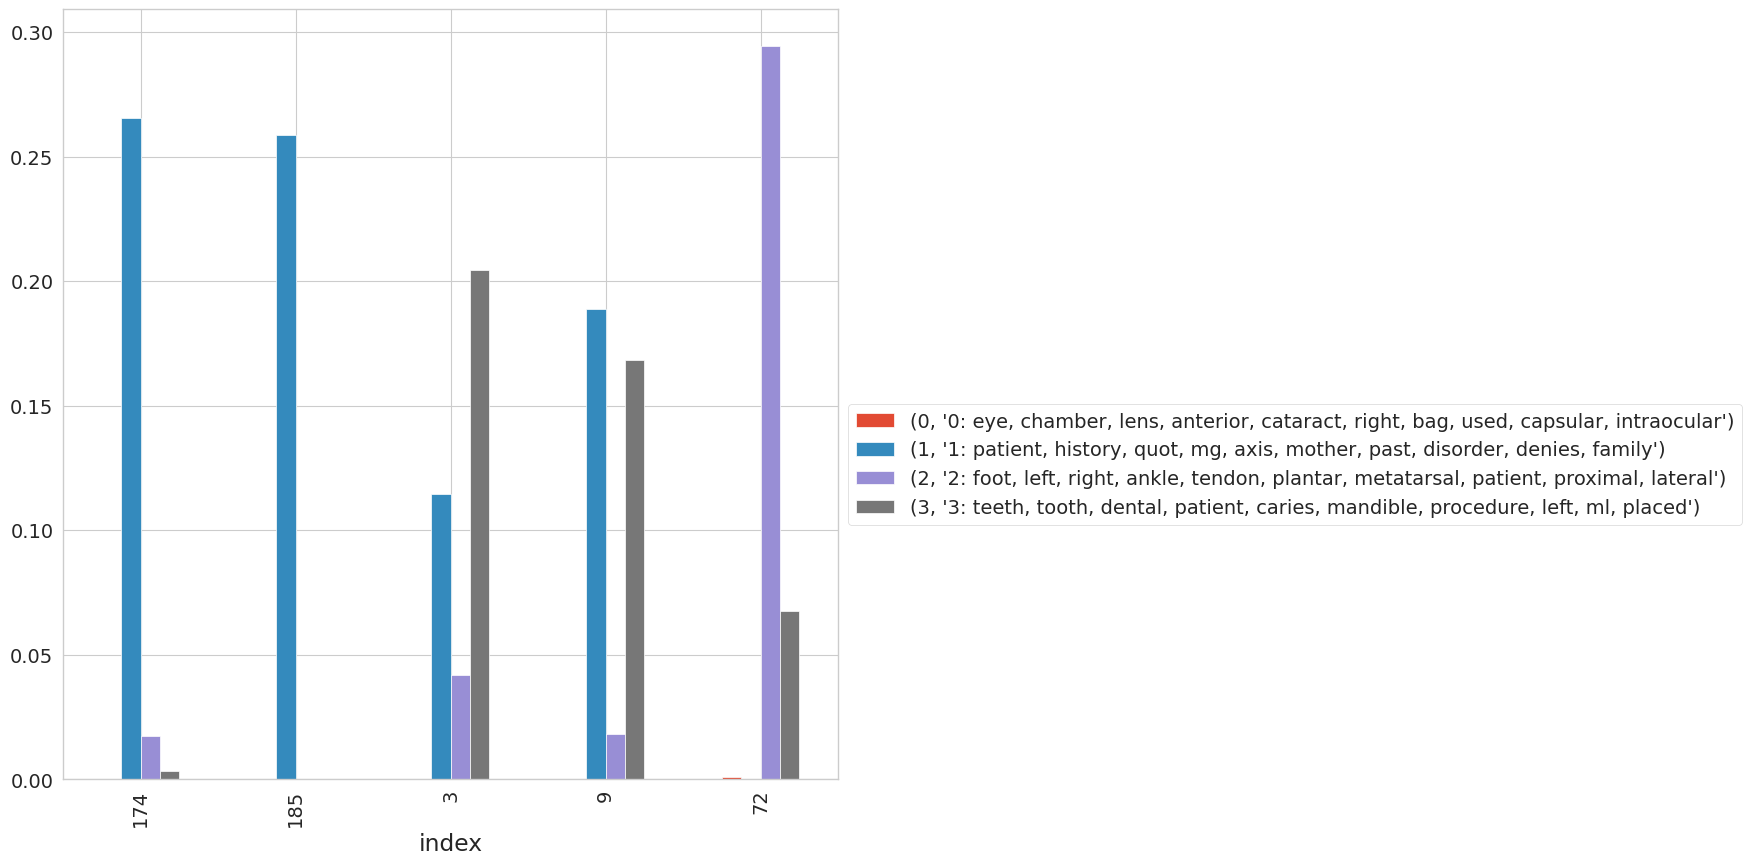

In [55]:
ax = tmp.plot.bar(figsize=(10,10), x='index')
ax.legend(tlist.items(), bbox_to_anchor=(1, 0.5));

Let's look at one of these documents

In [71]:
## choose a document index and assign value to i
i = 3
tmp[tmp['index']==i]

,index,topic0,topic1,topic2,topic3
3,3,0.0,0.114408,0.042058,0.204487


In [72]:
## which category did it belong to?
df_smaller[df_smaller['index']==i]

,Unnamed: 0,index,Category,Document Name,Document Content,Document words
478,478,3,17-dentistry,1916-odontogenicabscessid.txt,PREOPERATIVE D...,"[preoperative, diagnoses1, , left, facial, cel..."


In [73]:
## what's in the document? does the generated topic distribution make sense?
df_smaller[df_smaller['index']==i]['Document Content'].tolist()

['                                PREOPERATIVE DIAGNOSES:1.  Left facial cellulitis.2.  Possible odontogenic abscess of the #18, #19, and #20.POSTOPERATIVE DIAGNOSES:1.  Left facial cellulitis.2.  Possible odontogenic abscess of the #18, #19, and #20.PROCEDURE PERFORMED:  Attempted incision and drainage (I&D) of odontogenic abscess.ANESTHESIA:  1% lidocaine plain approximately 5 cc total.COMPLICATIONS:  The patient is very noncompliant with attempted procedure refusing further exam and treatment after localization and attempted FNA.  The attempted FNA was without any purulent aspirate although limited in the area of attempted examination.INDICATIONS FOR THE PROCEDURE:  The patient is a 39-year-old Caucasian female who was admitted to ABCD General Hospital on 08/21/03 secondary to acute left facial cellulitis suspected to be secondary to odontogenic etiology.  The patient states that this was started approximately 24 hours ago.  The patient subsequently presented to ABCD General Hospita

In [74]:
## this is another example
i = 72
tmp[tmp['index']==i]

,index,topic0,topic1,topic2,topic3
72,72,0.00116,0.0,0.294388,0.067724


In [75]:
df_smaller[df_smaller['index']==i]

,Unnamed: 0,index,Category,Document Name,Document Content,Document words
4862,4862,72,71-podiatry,2481-neuromaexcision.txt,PREOPERATIVE D...,"[preoperative, diagnosis, , morton, s, neuroma..."


In [76]:
df_smaller[df_smaller['index']==i]['Document Content'].tolist()

["                                PREOPERATIVE DIAGNOSIS:  Morton's neuroma, third interspace, left foot.POSTOPERATIVE DIAGNOSIS:  Morton's neuroma, third interspace, left foot.OPERATION PERFORMED:  Excision of neuroma, third interspace, left foot.ANESTHESIA:  General (local was confirmed by surgeon).HEMOSTASIS:  Ankle pneumatic tourniquet 225 mmHg.TOURNIQUET TIME:  18 minutes.  Electrocautery was necessary.INJECTABLES:  50:50 mixture of 0.5% Marcaine and 1% Xylocaine, both plain.  Also, 0.5 mL dexamethasone phosphate (4 mg/mL).INDICATIONS:  Please see dictated H&P for specifics.PROCEDURE:  After proper identification was made, the patient was brought to the operating room and placed on the table in supine position.  The patient was then placed under general anesthesia.  A local block was then injected into the third ray of the left foot.  The left foot was then prepped with chlorhexidine gluconate and then draped in the usual sterile technique.  The left foot was then exsanguinated wi